# Задание 4. Логистика и поставки

In [1]:
import sys, os
sys.path.insert(0, '/home/jovyan/work/etl')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from io_utils import read_table, write_mart, write_mart_to_pg, pg_engine

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')


## Загрузка

In [2]:
deliveries = read_table('deliveries')
deliveries['delivery_date'] = pd.to_datetime(deliveries['delivery_date'])
print(deliveries.shape)
print('NULL:'); print(deliveries.isna().sum())
deliveries.head()


(500, 10)
NULL:
delivery_id      0
delivery_date    0
route_from       0
route_to         0
distance_km      0
volume_tons      0
cost_rub         0
delay_hours      0
weather          0
driver           0
dtype: int64


,delivery_id,delivery_date,route_from,route_to,distance_km,volume_tons,cost_rub,delay_hours,weather,driver
0,105,2025-01-01,Ромашкино,Уфа,1448.28,27.59,206307.52,1.04,rain,Сидоров
1,252,2025-01-01,Ромашкино,Казань,1134.28,38.89,154391.70,0.00,storm,Сидоров
2,196,2025-01-01,Ромашкино,Казань,978.90,10.42,66581.92,8.79,storm,Петров
3,458,2025-01-02,Приобск,Москва,2589.33,28.43,84795.07,2.07,snow,Кузнецов
4,201,2025-01-03,Ромашкино,Казань,3329.99,24.26,86174.33,0.00,fog,Петров


## Фичи

In [3]:
df = deliveries.copy()
df = df[df['distance_km'] > 0]
df['cost_per_km']  = (df['cost_rub'] / df['distance_km']).round(2)
df['cost_per_ton'] = (df['cost_rub'] / df['volume_tons']).round(2)
df['route']        = df['route_from'] + ' → ' + df['route_to']
df['is_delayed']   = (df['delay_hours'] > 2).astype(int)
df.head()


,delivery_id,delivery_date,route_from,route_to,distance_km,volume_tons,cost_rub,delay_hours,weather,driver,cost_per_km,cost_per_ton,route,is_delayed
0,105,2025-01-01,Ромашкино,Уфа,1448.28,27.59,206307.52,1.04,rain,Сидоров,142.45,7477.62,Ромашкино → Уфа,0
1,252,2025-01-01,Ромашкино,Казань,1134.28,38.89,154391.70,0.00,storm,Сидоров,136.11,3969.96,Ромашкино → Казань,0
2,196,2025-01-01,Ромашкино,Казань,978.90,10.42,66581.92,8.79,storm,Петров,68.02,6389.82,Ромашкино → Казань,1
3,458,2025-01-02,Приобск,Москва,2589.33,28.43,84795.07,2.07,snow,Кузнецов,32.75,2982.59,Приобск → Москва,1
4,201,2025-01-03,Ромашкино,Казань,3329.99,24.26,86174.33,0.00,fog,Петров,25.88,3552.12,Ромашкино → Казань,0


## Влияние погоды

In [4]:
weather_stats = (
    df.groupby('weather', as_index=False)
      .agg(avg_delay=('delay_hours', 'mean'),
           delayed_pct=('is_delayed', 'mean'),
           count=('delivery_id', 'count'))
)
weather_stats['delayed_pct'] = (weather_stats['delayed_pct'] * 100).round(1)
weather_stats['avg_delay']   = weather_stats['avg_delay'].round(2)
weather_stats.sort_values('avg_delay', ascending=False)


,weather,avg_delay,delayed_pct,count
3,snow,6.42,86.8,136
4,storm,5.74,67.2,58
1,fog,2.19,31.2,112
2,rain,1.38,19.7,127
0,clear,1.04,23.9,67


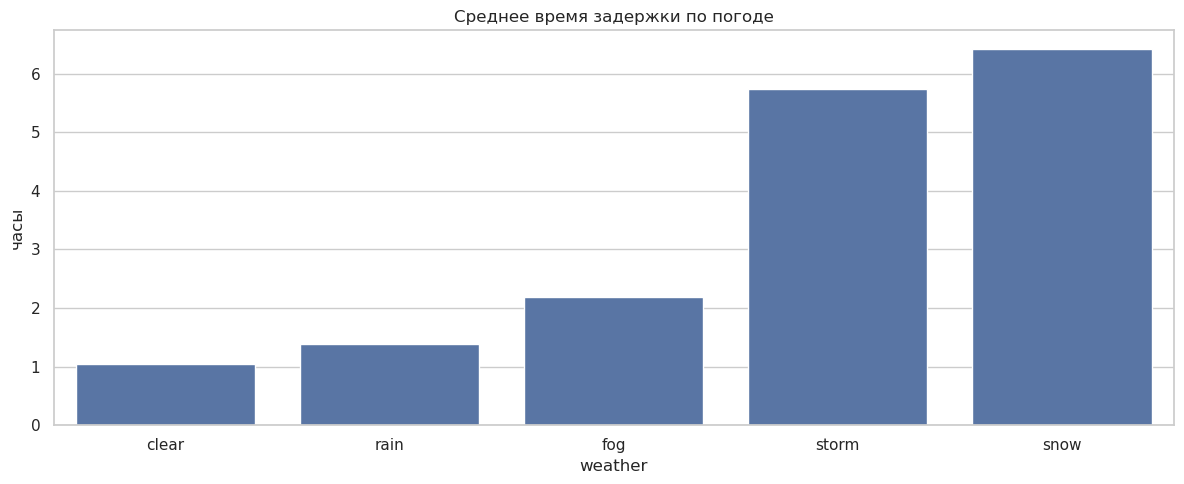

In [5]:
sns.barplot(data=weather_stats, x='weather', y='avg_delay',
            order=weather_stats.sort_values('avg_delay')['weather'])
plt.title('Среднее время задержки по погоде')
plt.ylabel('часы'); plt.tight_layout(); plt.show()


## Cost vs Distance

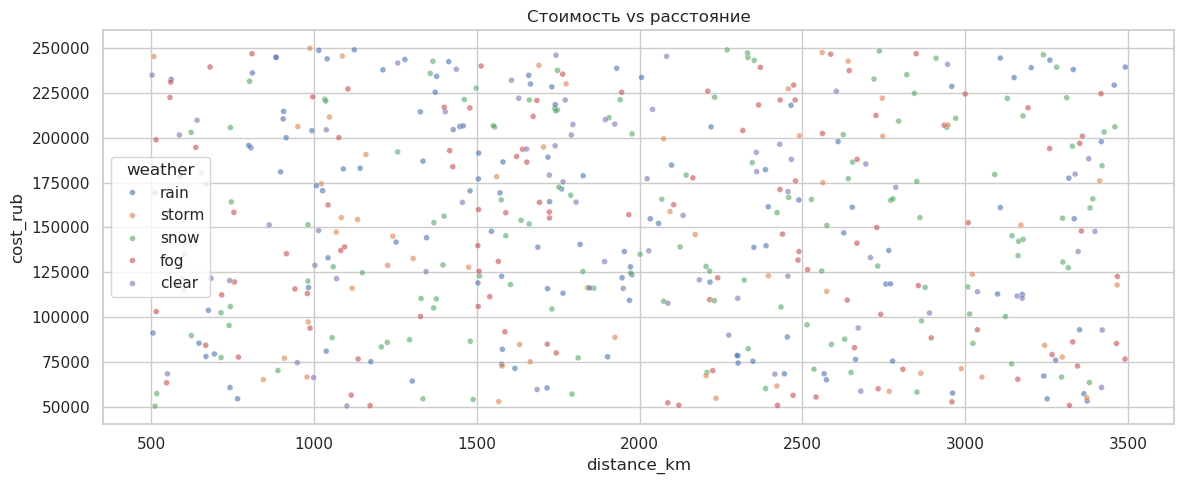

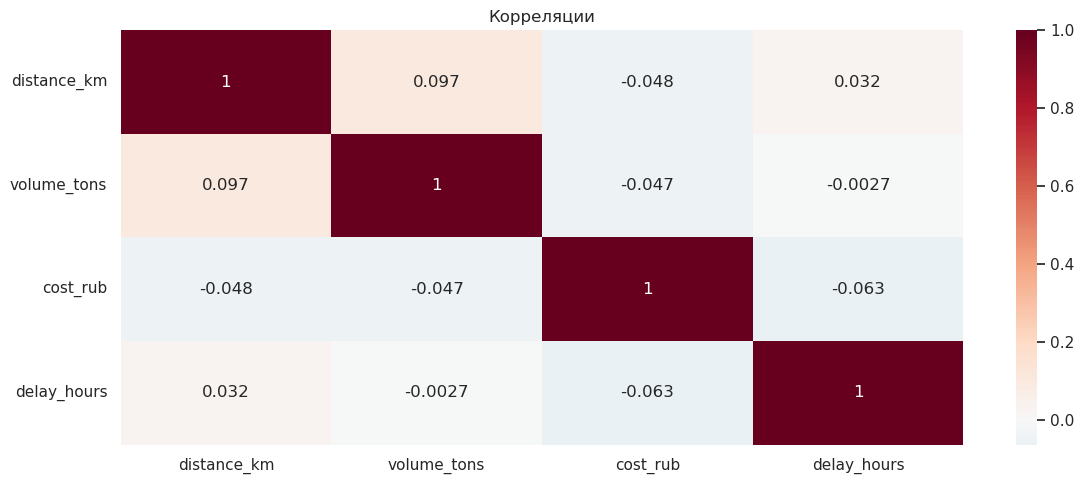

In [6]:
sns.scatterplot(data=df, x='distance_km', y='cost_rub', hue='weather', alpha=0.6, s=18)
plt.title('Стоимость vs расстояние'); plt.tight_layout(); plt.show()

corr = df[['distance_km', 'volume_tons', 'cost_rub', 'delay_hours']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Корреляции'); plt.tight_layout(); plt.show()


## KPI водителей

In [7]:
driver_kpi = (
    df.groupby('driver', as_index=False)
      .agg(trips=('delivery_id', 'count'),
           avg_delay=('delay_hours', 'mean'),
           avg_cost_per_km=('cost_per_km', 'mean'),
           total_volume=('volume_tons', 'sum'),
           delayed_share=('is_delayed', 'mean'))
)
driver_kpi['delayed_share']  = (driver_kpi['delayed_share'] * 100).round(1)
driver_kpi['avg_delay']      = driver_kpi['avg_delay'].round(2)
driver_kpi['avg_cost_per_km']= driver_kpi['avg_cost_per_km'].round(2)
driver_kpi.sort_values('avg_delay')


,driver,trips,avg_delay,avg_cost_per_km,total_volume,delayed_share
3,Попов,47,2.28,84.24,1466.72,38.3
0,Иванов,55,2.97,88.90,1638.84,47.3
5,Смирнов,70,3.30,105.96,1931.90,48.6
1,Кузнецов,106,3.49,98.40,3102.30,46.2
2,Петров,127,3.49,102.32,3602.62,47.2
4,Сидоров,95,4.03,97.62,2832.14,48.4


## Маршруты

In [8]:
route_stats = (
    df.groupby('route', as_index=False)
      .agg(trips=('delivery_id', 'count'),
           avg_cost_per_km=('cost_per_km', 'mean'),
           avg_delay=('delay_hours', 'mean'),
           total_cost=('cost_rub', 'sum'))
      .sort_values('avg_cost_per_km', ascending=False)
)
route_stats.head(10)


,route,trips,avg_cost_per_km,avg_delay,total_cost
23,Самотлор → Уфа,6,154.643333,8.201667,932499.85
27,Уренгой → Новосибирск,9,145.641111,3.644444,1793276.15
26,Уренгой → Москва,13,134.550000,1.462308,1820472.87
3,Ванкор → Новосибирск,21,114.177143,1.792857,3266308.46
1,Ванкор → Краснодар,33,111.086061,4.006364,4561204.25
18,Самотлор → Казань,9,108.596667,4.902222,1302817.43
0,Ванкор → Казань,21,108.398095,2.095238,3566286.17
17,Ромашкино → Уфа,7,104.260000,3.960000,950733.55
24,Уренгой → Казань,32,102.938125,2.151875,5204776.29
12,Ромашкино → Казань,15,102.787333,2.994000,2187123.69


## Сохранение

In [9]:
mart_logistics = df[['delivery_date', 'route', 'route_from', 'route_to',
                     'distance_km', 'volume_tons', 'cost_rub',
                     'cost_per_km', 'cost_per_ton',
                     'delay_hours', 'is_delayed', 'weather', 'driver']].copy()

write_mart(mart_logistics, 'mart_logistics')
write_mart_to_pg(mart_logistics, 'mart_logistics')
write_mart_to_pg(driver_kpi,    'mart_driver_kpi')
write_mart_to_pg(weather_stats, 'mart_weather_delay')
print('Saved')


Saved
